# Л1 — Підготовка даних

Велика частина роботи в Data Science — збір і підготовка даних. Саме тут виникає багато неочікуваних проблем і пасток.

Ноутбук нижче базово показує, як працювати з даними й готувати їх. Він не охоплює всіх можливих сценаріїв, а приклади в ньому часом сильно спрощені. Проте він дасть розуміння, де шукати помилки і як з ними боротися. Більше туторіалів — у [Kaggle Learn](https://www.kaggle.com/learn), зокрема [Data Cleaning](https://www.kaggle.com/learn/data-cleaning).

Базовий алгоритм підготовки даних може виглядати так (у дужках — кроки цього ноутбука):

- зчитування даних і початкове дослідження (1);
- дослідження структури й особливостей даних, зміна типів (2);
- об'єднання даних з різних джерел (3–4);
- робота з пропущеними й зламаними значеннями: drop, fill тощо (5, 7, 8);
- пошук outliers: drop, clip тощо (6);
- пошук зайвих і бракуючих колонок (9).

І головне: з кожною дією треба бути обережним. Outliers можуть бути реальними даними, які логічно пояснюються і які не можна видаляти. А пропущені значення можуть щось означати й бути корисними. Обидва випадки є в цій роботі.

Далі бувають кроки, специфічні для певних моделей чи алгоритмів:

- scaling: normalization, standardization тощо;
- обробка категорійних колонок: one-hot encoding тощо;
- dimensionality reduction.

Тут вони не розглядаються, частину з них побачите в Л2 і Л3.

Шаблон веде покроково: у кожному кроці — навіщо він і що зробити, у клітинці з `TODO` — ваш код. Опис даних і таблиця недоліків — у `README.md`.

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

## 1. Завантаження даних

На цьому етапі важливо впевнитися, що файли завантажено правильно, і подивитися, що взагалі всередині. Можуть допомогти `df.head()`, `df.tail()`, `df.shape` і `df.dtypes`.

Що ви маєте зрозуміти?

- Чи зчиталися дані взагалі?
- Чи правильно розпарсилися рядки, колонки й значення?
- Які типи в колонок?
- Які приблизно значення?
- Скільки рядків і колонок?

In [48]:
df_meters = pd.read_parquet("./data/meters.parquet")
df_registry = pd.read_csv("./data/registry.csv")

print("=== meters ===")
print("shape:", df_meters.shape)
print(df_meters.dtypes)
print(df_meters.head())

print("\n=== registry ===")
print("shape:", df_registry.shape)
print(df_registry.dtypes)
print(df_registry.head())

=== meters ===
shape: (516377, 4)
meter_id                   object
ts                 datetime64[us]
consumption_kwh           float64
record_ts          datetime64[us]
dtype: object
   meter_id                  ts  consumption_kwh           record_ts
0  UA100371 2026-01-05 00:00:00           0.5864 2026-01-05 00:11:32
1  UA100371 2026-01-05 01:00:00           0.4289 2026-01-05 01:09:24
2  UA100371 2026-01-05 02:00:00           0.4436 2026-01-05 02:05:00
3  UA100371 2026-01-05 03:00:00           0.5743 2026-01-05 03:14:32
4  UA100371 2026-01-05 04:00:00           0.3897 2026-01-05 04:02:12

=== registry ===
shape: (800, 7)
meter_id            object
customer_type       object
tariff              object
electric_heating     int64
connection_year      int64
years_connected      int64
district            object
dtype: object
   meter_id   customer_type     tariff  electric_heating  connection_year  \
0  UA100371       household  dual_zone                 0             1989   
1  UA103727

## 2. Звірка з описом

Іноді бізнес надає опис ідеальних даних, але реальні дані часто з ним не збігаються. Тому спершу подивіться, чи ваші дані відповідають опису в `README.md`. Може допомогти `df.describe()`.

Перевірте (але поки не виправляйте):

- типи колонок: якщо число прочиталося як текст, частина операцій спрацює неправильно;
- скільки рядків мають `customer_type`, `tariff` чи `electric_heating`, яких немає в описі;
- скільки рядків мають `ts`, `connection_year` чи `years_connected` поза межами з опису;
- скільки різних лічильників у кожному файлі — мають бути по 800.

Можуть допомогти `isin`, `between` і `nunique`.

Недоліки з таблиці в `README.md` перевірятимете далі, кожен у своєму кроці. Межі споживання залежать від типу абонента, а тип є лише в реєстрі, тому їх перевірите після об'єднання, на кроці 6.

In [49]:
print("=== meters ===")
print("unique meters:", df_meters["meter_id"].nunique())
print("ts range:", df_meters["ts"].min(), "—", df_meters["ts"].max())
print("========")
print(df_meters.describe())

print("\n=== registry ===")
print("unique meters:", df_registry["meter_id"].nunique())

valid_customer_types = {"household", "small_business", "industrial"}
valid_tariffs = {"single", "dual_zone"}
valid_districts = {"Podil", "Solomianka", "Darnytsia", "Obolon", "Sviatoshyn"}

print("invalid customer_type:", (~df_registry["customer_type"].isin(valid_customer_types)).sum())
print("invalid tariff:", (~df_registry["tariff"].isin(valid_tariffs)).sum())
print("invalid electric_heating:", (~df_registry["electric_heating"].isin([0, 1])).sum())
print("invalid district:", (~df_registry["district"].isin(valid_districts)).sum())
print("connection_year out of range:", (~df_registry["connection_year"].between(1985, 2024)).sum())
print("years_connected out of range:", (~df_registry["years_connected"].between(1, 41)).sum())
print("========")
print(df_registry.describe())


=== meters ===
unique meters: 800
ts range: 2026-01-05 00:00:00 — 2026-02-01 23:00:00
                               ts  consumption_kwh                   record_ts
count                      516377    516377.000000                      516377
mean   2026-01-18 18:46:08.881650       507.304644  2026-01-18 18:54:08.409368
min           2026-01-05 00:00:00         0.019400         2026-01-05 00:01:00
25%           2026-01-11 19:00:00         0.418900         2026-01-11 19:12:46
50%           2026-01-18 16:00:00         0.925400         2026-01-18 16:02:46
75%           2026-01-25 17:00:00         2.538200         2026-01-25 17:13:12
max           2026-02-01 23:00:00    182250.300000         2026-02-01 23:14:59
std                           NaN      5493.236177                         NaN

=== registry ===
unique meters: 800
invalid customer_type: 0
invalid tariff: 0
invalid electric_heating: 0
invalid district: 80
connection_year out of range: 0
years_connected out of range: 0
       ele

## 3. Реєстр: номери й райони (D-E, D-F)

Дані зберігаються в різних системах, тому формат ідентифікатора може не збігатися: `" UA123456"` для pandas — інший номер, ніж `UA123456`. Наївний join призведе до того, що частина даних втратиться. Так само `podil` і `Podil` — різні райони, і будь-який підрахунок по районах буде хибним.

Для D-E і D-F виведіть, скільки рядків реєстру зіпсовано, і виправте їх так, як сказано в таблиці недоліків. Можуть допомогти `str.fullmatch(r"UA\d{6}")`, `isin`, `str.strip()`, `str.lstrip("0")` і `str.capitalize()`.

In [50]:
# D-E — зіпсовані номери в реєстрі
broken_ids = ~df_registry["meter_id"].str.fullmatch(r"UA\d{6}")
print("Invalid ids count:", broken_ids.sum())

df_registry["meter_id"] = (
    df_registry["meter_id"]
    .str.strip()
    .str.lstrip("0")
    .str.strip()
)
print("Invalid ids count after matching:", (~df_registry["meter_id"].str.fullmatch(r"UA\d{6}")).sum())

# D-F — неправильне написання районів
valid_districts = ["Podil", "Solomianka", "Darnytsia", "Obolon", "Sviatoshyn"]
broken_districts = ~df_registry["district"].isin(valid_districts)
print("\nInvalid regions count:", broken_districts.sum())

df_registry["district"] = df_registry["district"].str.strip().str.capitalize()
print("Invalid regions count after capitalizing:", (~df_registry["district"].isin(valid_districts)).sum())


Invalid ids count: 96
Invalid ids count after matching: 0

Invalid regions count: 80
Invalid regions count after capitalizing: 0


## 4. Об'єднання

Тепер погодинні дані можна об'єднати з реєстром за `meter_id` (join, у pandas — `merge`). pandas не попереджає, коли рядок не знайшов пари, тому якість об'єднання треба перевірити самому.

Об'єднану таблицю назвіть `df`, з нею працюватимете далі. Перевірте й виведіть:

- кількість рядків до і після об'єднання — вона не має змінитися;
- кількість рядків без атрибутів абонента (пропуск у `customer_type`) — має бути 0.

Може допомогти `merge(..., how="left", validate="m:1")`: `validate` ще й перевірить, що кожному лічильнику відповідає один рядок реєстру.

In [51]:
rows_before_merge = len(df_meters)
print("Rows before merge:", rows_before_merge)

meter_readings = df_meters.merge(df_registry, on="meter_id", how="left", validate="m:1")

print("Rows after merge:", len(meter_readings))
print("Rows missing customer type:", meter_readings["customer_type"].isna().sum())


Rows before merge: 516377
Rows after merge: 516377
Rows missing customer type: 0


## 5. Повторні відправки (D-C)

Повторна відправка — та сама година того самого лічильника ще раз, іноді з уточненим значенням. Якщо лишити обидва записи, споживання за цю годину подвоїться. Лишаємо найпізніший за `record_ts` запис як найсвіжіший.

Виведіть кількість рядків і кількість різних пар `meter_id` і `ts`, потім зніміть повтори. Можуть допомогти `duplicated(["meter_id", "ts"])`, `sort_values("record_ts")` і `drop_duplicates(["meter_id", "ts"], keep="last")`.

In [52]:
# D-C — duplicate submissions
print("Rows count:", len(meter_readings))
print("Unique meter_id + ts pairs:", meter_readings[["meter_id", "ts"]].drop_duplicates().shape[0])

rows_before_dedup = len(meter_readings)
meter_readings = (
    meter_readings
    .sort_values("record_ts")
    .drop_duplicates(["meter_id", "ts"], keep="last")
)
print("Rows after removing duplicates:", len(meter_readings))
print("Duplicates removed:", rows_before_dedup - len(meter_readings))


Rows count: 516377
Unique meter_id + ts pairs: 516377
Rows after removing duplicates: 516377
Duplicates removed: 0


## 6. Одиниці виміру (D-D)

Значення у Вт·год схожі на викиди, але це не шум, а помилка одиниць. Якщо їх видалити, зникнуть цілі абоненти.

1. Для кожного лічильника порахуйте відношення його медіани `consumption_kwh` до медіани всіх рядків його `customer_type`. Більше 100 — лічильник звітує у Вт·год.
2. Побудуйте графік медіан лічильників за `customer_type` з логарифмічною віссю, наприклад boxplot.
3. Виведіть кількість лічильників у Вт·год, найбільше відношення серед решти лічильників і найменше серед лічильників у Вт·год (якщо таких немає — лише найбільше відношення серед усіх). Ці числа — доказ у звіті: вони показують, наскільки далеко від порога обидві групи.
4. Поділіть значення цих лічильників на 1000 і виведіть, скільки рядків поза межами споживання з опису, — має бути 0.

Можуть допомогти `DataFrame.boxplot(column=..., by="customer_type")`, `plt.yscale("log")` і `between`. Клітинку з діленням не запускайте двічі: значення поділяться ще раз. Якщо так сталося, перезапустіть ноутбук з початку.

Total meters:                             800
Meters reporting in Wh (watt-hours):      64 (8.0% of total)
Meters reporting in kWh (kilowatt-hours): 736 (92.0% of total)
Highest ratio among kWh meters: 4.49
Lowest ratio among Wh meters: 298.33


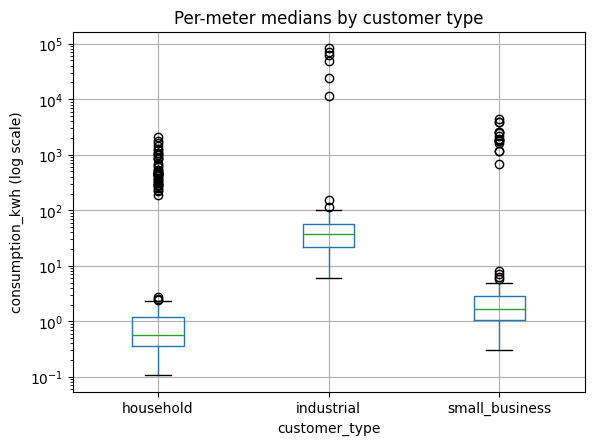

Rows out of range after fix: 0


In [53]:
# D-D — wrong units (Wh instead of kWh)
meter_median = meter_readings.groupby("meter_id")["consumption_kwh"].median()
meter_type = meter_readings.groupby("meter_id")["customer_type"].first()
type_median = meter_readings.groupby("customer_type")["consumption_kwh"].median()
ratio = meter_median / meter_type.map(type_median)

wh_meters = ratio[ratio > 100].index
kwh_meters = ratio[ratio <= 100].index

total_meters = meter_readings["meter_id"].nunique()
print(f"Total meters:                             {total_meters}")
print(f"Meters reporting in Wh (watt-hours):      {len(wh_meters)} ({len(wh_meters) / total_meters:.1%} of total)")
print(f"Meters reporting in kWh (kilowatt-hours): {len(kwh_meters)} ({len(kwh_meters) / total_meters:.1%} of total)")

if len(wh_meters) > 0 and len(wh_meters) < total_meters:
    print("Highest ratio among kWh meters:", ratio[ratio.index.isin(kwh_meters)].max().round(2))
    print("Lowest ratio among Wh meters:", ratio[ratio.index.isin(wh_meters)].min().round(2))
else:
    print("Highest ratio among all meters:", ratio.max().round(2))

# boxplot of per-meter medians grouped by customer type
meter_medians = pd.DataFrame({"median": meter_median, "customer_type": meter_type})
meter_medians.boxplot(column="median", by="customer_type")
plt.yscale("log")
plt.title("Per-meter medians by customer type")
plt.suptitle("")
plt.ylabel("consumption_kwh (log scale)")
plt.show()

# divide Wh meters by 1000 to convert to kWh
meter_readings.loc[meter_readings["meter_id"].isin(wh_meters), "consumption_kwh"] /= 1000

min_kwh = {"household": 0.01, "small_business": 0.02, "industrial": 1}
max_kwh = {"household": 10, "small_business": 60, "industrial": 1200}
out_of_range = ~meter_readings["consumption_kwh"].between(
    meter_readings["customer_type"].map(min_kwh),
    meter_readings["customer_type"].map(max_kwh)
)
print("Rows out of range after fix:", out_of_range.sum())


## 7. Лічильники, що замовкли (D-A)

Пропуски не заповнюємо: те, що лічильник замовк, уже є інформацією про можливу відмову, а середнє її стерло б. Не видаляємо теж: до відмови лічильник передавав правильні дані.

Для кожного лічильника порахуйте, скільки годин минуло від його останнього `ts` до `2026-02-01 23:00`; більше 48 — замовк. Як на кроці 6, виведіть кількість замовклих, найбільшу тишу серед решти й найменшу серед замовклих (якщо замовклих немає — лише найбільшу тишу серед усіх).

Номери замовклих лічильників збережіть списком `silent`, наприклад `list(....index)`: він знадобиться в регресії.

Можуть допомогти `pd.Timestamp("2026-02-01 23:00")` і `/ pd.Timedelta(hours=1)`.

In [54]:
# D-A — silent meters (stopped transmitting data)
end_ts = pd.Timestamp("2026-02-01 23:00")
last_ts_per_meter = meter_readings.groupby("meter_id")["ts"].max()
silence_hours = (end_ts - last_ts_per_meter) / pd.Timedelta(hours=1)

silent = list(silence_hours[silence_hours > 48].index)

total_meters = meter_readings["meter_id"].nunique()
print(f"Total meters:  {total_meters}")
print(f"Silent meters: {len(silent)} ({len(silent) / total_meters:.1%} of total)")

if len(silent) > 0 and len(silent) < total_meters:
    print("Longest silence among active meters (h):", silence_hours[~silence_hours.index.isin(silent)].max().round(1))
    print("Shortest silence among silent meters (h):", silence_hours[silence_hours.index.isin(silent)].min().round(1))
else:
    print("Longest silence among all meters (h):", silence_hours.max().round(1))


Total meters:  800
Silent meters: 48 (6.0% of total)
Longest silence among active meters (h): 1.0
Shortest silence among silent meters (h): 144.0


## 8. Завмерлі лічильники (D-B)

Завмерлі значення виглядають правдоподібно, і ні середнє, ні максимум їх не видають. Помітно лише те, що значення перестали змінюватися. Такі лічильники не видаляємо: частина їхніх годин справна.

Для кожного лічильника порахуйте частку різних значень `consumption_kwh` серед його записів; менше 0.65 — завмер. Побудуйте гістограму цієї частки по лічильниках. Як на кроці 6, виведіть кількість завмерлих, найменшу частку серед решти й найбільшу серед завмерлих (якщо завмерлих немає — лише найменшу частку серед усіх).

Номери завмерлих лічильників збережіть списком `frozen`: він знадобиться в регресії.

Можуть допомогти `nunique()`, `size()` і `plt.hist`.

Total meters:   800
Frozen meters:  40 (5.0% of total)
Lowest ratio among normal meters: 0.844
Highest ratio among frozen meters: 0.498


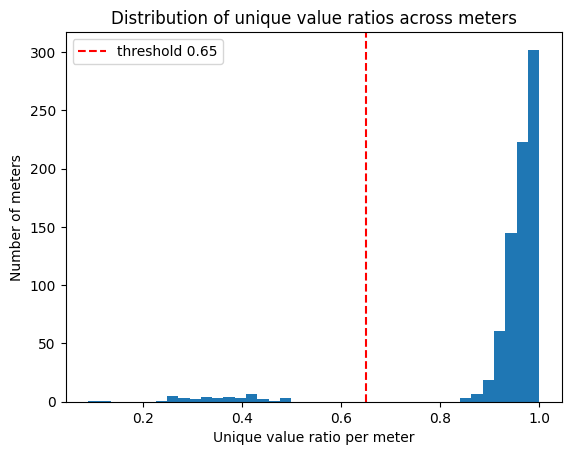

In [55]:
# D-B — frozen meters (transmitting the same value repeatedly)
unique_value_ratio = meter_readings.groupby("meter_id")["consumption_kwh"].apply(
    lambda x: x.nunique() / x.size
)

frozen = list(unique_value_ratio[unique_value_ratio < 0.65].index)

total_meters = meter_readings["meter_id"].nunique()
print(f"Total meters:   {total_meters}")
print(f"Frozen meters:  {len(frozen)} ({len(frozen) / total_meters:.1%} of total)")

if len(frozen) > 0 and len(frozen) < total_meters:
    print("Lowest ratio among normal meters:", unique_value_ratio[~unique_value_ratio.index.isin(frozen)].min().round(3))
    print("Highest ratio among frozen meters:", unique_value_ratio[unique_value_ratio.index.isin(frozen)].max().round(3))
else:
    print("Lowest ratio among all meters:", unique_value_ratio.min().round(3))

plt.hist(unique_value_ratio, bins=40)
plt.xlabel("Unique value ratio per meter")
plt.ylabel("Number of meters")
plt.title("Distribution of unique value ratios across meters")
plt.axvline(0.65, color="red", linestyle="--", label="threshold 0.65")
plt.legend()
plt.show()


## 9. Кореляції

Колонка, що майже копіює іншу, не додає інформації: у кластеризації вона подвоює вагу того самого фактора, а в регресії робить коефіцієнти нестабільними. Технічна колонка `record_ts` після кроку 5 теж не потрібна.

Порахуйте кореляції між числовими колонками об'єднаної таблиці. Пару з кореляцією за модулем понад 0.95 вважайте копією і лиште з неї одну колонку. Приберіть `record_ts`. Підсумкову таблицю назвіть `result`.

Можуть допомогти `select_dtypes("number").corr().abs()` і `drop(columns=...)`.

In [56]:
corr_matrix = meter_readings.select_dtypes("number").corr().abs()
print(corr_matrix)

highly_correlated_pairs = [
    (a, b)
    for a in corr_matrix.columns
    for b in corr_matrix.columns
    if a < b and corr_matrix.loc[a, b] > 0.95
]
print("\nColumn pairs with correlation > 0.95:", highly_correlated_pairs)

redundant_columns = [pair[1] for pair in highly_correlated_pairs]
result = meter_readings.drop(columns=redundant_columns + ["record_ts"])
print("Remaining columns:", list(result.columns))


                  consumption_kwh  electric_heating  connection_year  \
consumption_kwh           1.00000          0.103960         0.018580   
electric_heating          0.10396          1.000000         0.026220   
connection_year           0.01858          0.026220         1.000000   
years_connected           0.01878          0.024083         0.999047   

                  years_connected  
consumption_kwh          0.018780  
electric_heating         0.024083  
connection_year          0.999047  
years_connected          1.000000  

Column pairs with correlation > 0.95: [('connection_year', 'years_connected')]
Remaining columns: ['meter_id', 'ts', 'consumption_kwh', 'customer_type', 'tariff', 'electric_heating', 'connection_year', 'district']


## 10. Самоперевірка й збереження

Якщо якась перевірка падає, поверніться до відповідного кроку.

In [57]:
districts = ["Podil", "Solomianka", "Darnytsia", "Obolon", "Sviatoshyn"]
min_kwh = {"household": 0.01, "small_business": 0.02, "industrial": 1}
max_kwh = {"household": 10, "small_business": 60, "industrial": 1200}
corr = result.select_dtypes("number").corr().abs()
copies = [(a, b) for a in corr for b in corr if a < b and corr.loc[a, b] > 0.95]

assert not result.duplicated(["meter_id", "ts"]).any(), "лишилися повтори лічильник–година"
assert result["meter_id"].nunique() == 800, "лічильників має бути 800"
assert result["meter_id"].str.fullmatch(r"UA\d{6}").all(), "є номери не у форматі UA і 6 цифр"
assert result["customer_type"].notna().all(), "є рядки без атрибутів абонента"
assert result["district"].isin(districts).all(), "є райони, яких немає в описі"
assert result["consumption_kwh"].between(result["customer_type"].map(min_kwh), result["customer_type"].map(max_kwh)).all(), "є споживання поза межами з опису"
assert not copies, f"лишилися колонки-копії: {copies}"
assert "record_ts" not in result, "технічна колонка record_ts лишилася"

result.to_parquet("cleaned.parquet", index=False)
print("усе гаразд:", result.shape)

усе гаразд: (516377, 8)


## 11. Регресія

Регресію часто використовують, щоб передбачати певні показники. Проте лінійна регресія також показує, як кожен показник впливає на результат. Це і є регресійний аналіз.

Для прикладу подивимося, як на добове споживання домогосподарства впливають електроопалення і двозонний тариф: `y = a + b₁·x₁ + b₂·x₂`.

- `y` — середнє споживання лічильника за добу, кВт·год;
- `x₁` — `electric_heating`, `x₂` — двозонний тариф (обидва 0 або 1);
- `b₁` і `b₂` — на скільки кВт·год на добу більше споживає абонент із цим фактором за однакового іншого;
- `a` — споживання без опалення на звичайному тарифі;
- R² — яку частку розкиду споживання пояснюють обидва фактори, від 0 до 1.

Регресія тут краща за просте порівняння середніх: двозонний тариф здебільшого мають будинки з опаленням, і різниця середніх за тарифом приписала б тарифу ще й споживання на опалення.

Нормалізація не потрібна: обидва фактори мають однаковий масштаб (0 або 1), тож `b₁` і `b₂` можна порівнювати напряму, а `y` лишається в кВт·год на добу, і коефіцієнти легко пояснити. Якби фактори мали різні одиниці, наприклад площу і рік, для порівняння впливу їх спершу стандартизували б.

Лічильники з `silent` і `frozen` не беремо: у `cleaned.parquet` вони лишаються, але їхнє середнє споживання спотворене.

Код майже готовий: допишіть `homes` і запустіть.

In [ ]:
household_readings = result[
    (result["customer_type"] == "household") &
    (~result["meter_id"].isin(silent)) &
    (~result["meter_id"].isin(frozen))
]

per_meter = household_readings.groupby("meter_id").agg(
    kwh_per_day=("consumption_kwh", "mean"),
    electric_heating=("electric_heating", "first"),
    tariff=("tariff", "first"),
)
per_meter["kwh_per_day"] *= 24
per_meter["dual_zone"] = (per_meter["tariff"] == "dual_zone").astype(int)

features = per_meter[["electric_heating", "dual_zone"]]
daily_consumption = per_meter["kwh_per_day"]

model = LinearRegression().fit(features, daily_consumption)

baseline         = model.intercept_
heating_effect   = model.coef_[0]
dual_zone_effect = model.coef_[1]
r_squared        = model.score(features, daily_consumption)

print(f"Households in regression: {len(per_meter)}")
print()
print(f"Baseline daily consumption (no heating, single tariff): {baseline:.2f} kWh/day")
print(f"Extra consumption with electric heating:                {heating_effect:+.2f} kWh/day  ({heating_effect / baseline:.0%} of baseline)")
print(f"Extra consumption with dual-zone tariff:                {dual_zone_effect:+.2f} kWh/day  ({dual_zone_effect / baseline:.0%} of baseline)")
print()
print(f"R² = {r_squared:.3f}  (model explains {r_squared:.1%} of consumption variance)")
